In [24]:
import numpy as np
import pandas as pd
import itertools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [25]:
path =r"D:\Intern\Edu-Versity\Project 3\fake_or_real_news.csv"

In [26]:
df = pd.read_csv(path)

In [27]:
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [28]:
df.tail()

,Unnamed: 0,title,text,label
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL
6334,4330,Jeb Bush Is Suddenly Attacking Trump. Here's W...,Jeb Bush Is Suddenly Attacking Trump. Here's W...,REAL


In [29]:
target = df.label
target.head()

0    FAKE
1    FAKE
2    REAL
3    FAKE
4    REAL
Name: label, dtype: object

In [30]:
#Splitting the Dataset
x_train, x_test, y_train, y_test = train_test_split(df['text'], target, test_size=0.2, random_state=42)

In [31]:
#TfidfVectorize
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

In [32]:
# Fit and Transform Train,Transform Test
tfidf_train = tfidf_vectorizer.fit_transform(x_train)
tfidf_test = tfidf_vectorizer.transform(x_test)

In [33]:
# intializing a passiveAggressiveClassifier
classifier = PassiveAggressiveClassifier(max_iter=50)
classifier.fit(tfidf_train,y_train)

ypred = classifier.predict(tfidf_test)
accuracy_score = accuracy_score(y_test,ypred)
print(f"Accuracy of the Model: {round(accuracy_score*100,2)}%")

Accuracy of the Model: 93.92%


In [43]:
# confusion matrix
cm = confusion_matrix(y_test,ypred,labels = ['FAKE','REAL'])
print(cm)

[[589  39]
 [ 38 601]]


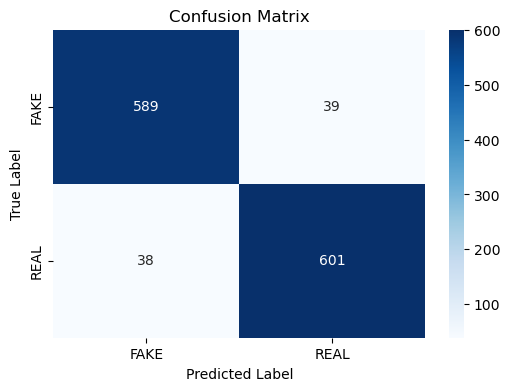

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Actual and predicted labels
labels = ['FAKE', 'REAL']

# Plotting the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
